<a href="https://colab.research.google.com/github/leajag/2025_ML_EES/blob/main/final_project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Common imports
import numpy as np
import matplotlib as plt
import pandas as pd
import os
import matplotlib.pyplot as plt

# Extra imports for data pre- processing
!pip install rasterio
import rasterio

!pip install geopandas
import geopandas as gpd

!pip install --upgrade pyshp

!pip install --upgrade shapely

!pip install --upgrade descartes

!pip install --upgrade rtree

from __future__ import print_function

from osgeo import ogr

#for CNN
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from keras.utils import plot_model
from sklearn.model_selection import train_test_split



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!ls /content/drive/MyDrive

'Albedo img'	    GEEDiT_export_LJ.geojson  'notebooks glacier'
'Colab Notebooks'   ML_project		      'RGB img'


In [4]:
data = np.load("/content/drive/MyDrive/ML_project/data_arrays.npz")
X = data['X']
y = data['y']

In [16]:
y_labels = y[:, 0, 0]  # takes left upper pixel per image, to ensure, that all classes are in test set

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y_labels)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2880, 3, 128, 128)
X_test shape: (320, 3, 128, 128)
y_train shape: (2880, 128, 128)
y_test shape: (320, 128, 128)


In [17]:
y_train_labels = y_train[:,0,0]  # upper left pixel to adjust labels as for all pixels in one image same class
y_test_labels = y_test[:,0,0]

**k-fold Cross validation:**

In [18]:
from sklearn.model_selection import StratifiedKFold # Generate test sets such that all contain the same distribution of classes, or as close as possible.

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # 5-Fold Stratified Cross Validation


In [19]:
X_base_train, y_base_train = X_train, y_train # Preserve the original training sets

for fold, (train_index, val_index) in enumerate(kf.split(X_base_train, y_train_labels)):

    # Assign to new variables for each fold to avoid modifying the original X_train and y_train
    X_fold_train, X_fold_valid = X_base_train[train_index], X_base_train[val_index]
    y_fold_train, y_fold_valid = y_base_train[train_index], y_base_train[val_index]
    y_fold_train_labels = y_train_labels[train_index]
    y_fold_valid_labels = y_train_labels[val_index]



In [9]:
print(X_fold_train.shape)
print(y_fold_train.shape)


(2304, 3, 128, 128)
(2304, 128, 128)


In [21]:
#flatten layer for LR and RFC to 2D array
# Flatten X_fold_train from (samples, channels, height, width) to (samples, features)

X_train_2D = X_fold_train.reshape(X_fold_train.shape[0], -1)
y_train_2D = y_fold_train.reshape(y_fold_train.shape[0], -1)

X_test_2D = X_test.reshape(X_test.shape[0], -1)
y_test_2D = y_test.reshape(y_test.shape[0], -1)

print("X train", X_fold_train.shape)
print("y test", y_test.shape)

print( "X train 2D", X_train_2D.shape)
print("X test 2D", X_test_2D.shape)
print("y train 2D", y_train_2D.shape)
print("y test 2D", y_test_2D.shape)




X train (2304, 3, 128, 128)
y test (320, 128, 128)
X train 2D (2304, 49152)
X test 2D (320, 49152)
y train 2D (2304, 16384)
y test 2D (320, 16384)


**Logistic Regression:**

In [22]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(multi_class = "multinomial",max_iter=1000, random_state=42)
clf.fit(X_train_2D, y_fold_train_labels) #takes: 1:15min


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42)

In [23]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

clf_preds = clf.predict(X_test_2D)
clf_acc = accuracy_score(y_test_labels, clf_preds)
print("CLF accuracy score:", clf_acc)


CLF accuracy score: 0.609375


**Random Forest:**

In [13]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier()
rfc.fit(X_train_2D, y_fold_train_labels)

RandomForestClassifier()

In [14]:
rfc_preds = rfc.predict(X_test_2D)
rfc_acc = accuracy_score(y_test_labels, rfc_preds)
print("RF accuracy score:", rfc_acc)


RF accuracy score: 0.628125


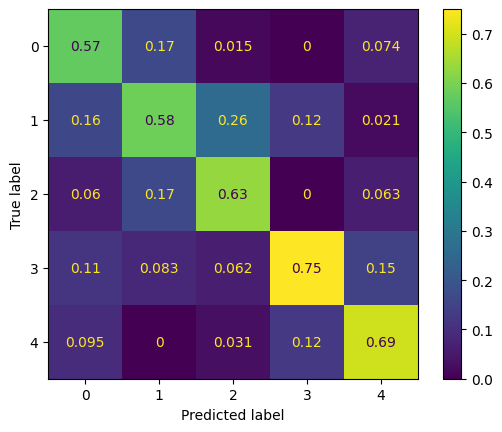

In [ ]:
cm = confusion_matrix(y_test_labels, rfc_preds, normalize="pred") # Get a confusion matrix 'cm', use 'pred' for the normalize option
disp = ConfusionMatrixDisplay(confusion_matrix = cm) # Use ConfusionMatrixDisplay to visualize 'cm'
disp.plot()


In [15]:
#RandomizedSearchCV for hyperparameter search -> took too long
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

rfc = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(2, 5),
    'max_features': ['sqrt']
}

random_search = RandomizedSearchCV(
    estimator=rfc,
    param_distributions=param_dist,
    n_iter=10,        # 50 zufällige Kombinationen
    cv=3,
    n_jobs=-1,
    verbose=2,
    scoring='accuracy',
    random_state=42
)

random_search.fit(X_train_2D, y_train_labels[train_index])
print("best parameters:",random_search.best_params_)
print("best score:", random_search.best_score_)



Fitting 3 folds for each of 10 candidates, totalling 30 fits


KeyboardInterrupt: 

**CNN:**
model1

In [24]:
# Reorganisation for Keras: transpose X_fold_train and X_fold_valid to (batch, height, width, channels)
X_fold_train_trans = np.transpose(X_fold_train, (0, 2, 3, 1))
X_fold_valid_trans = np.transpose(X_fold_valid, (0, 2, 3, 1))
X_test_trans = np.transpose(X_test, (0, 2, 3, 1))

In [25]:
model1 = tf.keras.Sequential()
input_img_shape = (X_train.shape[2], X_train.shape[3], X_train.shape[1]) #reorganisation of channels for Keras

In [26]:
#layers from 5.2 lab
#first layer: 16 filters, a 3x3 kernel size, a ReLU activation function and 'SAME' padding, weights are initialised by providing the input_shape argument in the first layer.
model1.add(tf.keras.layers.Conv2D(16,(3,3),padding='SAME', activation='relu',input_shape=input_img_shape,name='conv_1'))
model1.add(tf.keras.layers.Conv2D(8,(3,3),padding='SAME', activation='relu',name='conv_2'))
model1.add(MaxPooling2D((8,8),name='pool_1'))
model1.add(tf.keras.layers.Flatten(name='flatten'))
model1.add(tf.keras.layers.Dense(32, activation='relu',name='dense_1'))
model1.add(tf.keras.layers.Dense(10,activation='softmax',name='dense_2'))
model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 128, 128, 8)    │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │        65,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,506 (263.70 KB)

 Trainable params: 67,506 (263.70 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model1.compile(optimizer='adam',
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])

In [28]:
epochs = 40
history = model1.fit(X_fold_train_trans, y_fold_train_labels,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(X_fold_valid_trans, y_fold_valid_labels))

Epoch 1/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.2522 - loss: 11.6386 - val_accuracy: 0.3872 - val_loss: 1.5563
Epoch 2/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4262 - loss: 1.4481 - val_accuracy: 0.4688 - val_loss: 1.2608
Epoch 3/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5055 - loss: 1.2271 - val_accuracy: 0.5469 - val_loss: 1.1040
Epoch 4/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6225 - loss: 0.9698 - val_accuracy: 0.5035 - val_loss: 1.0969
Epoch 5/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6479 - loss: 0.8687 - val_accuracy: 0.5920 - val_loss: 1.0044
Epoch 6/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6700 - loss: 0.7989 - val_accuracy: 0.5851 - val_loss: 0.9967
Epoch 7/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6623 - loss: 0.8082 - val_accuracy: 0.5642 - val_loss: 1.0288
Epoch 8/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6158 - loss: 0.8752 - val_accuracy: 0.5868 -

In [29]:
score_model1 = model1.evaluate(X_test_trans, y_test_labels)
print('Test accuracy: {acc:0.3f}'.format(acc=score_model1[1]))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7197 - loss: 1.5302 
Test accuracy: 0.706


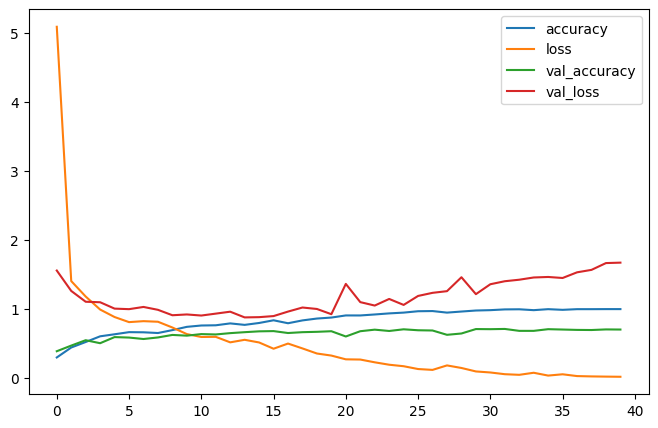

In [30]:
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.show()

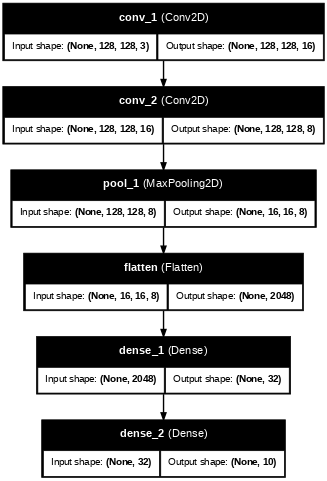

In [ ]:
# Plot the model using Keras model plotting utilities
tf.keras.utils.plot_model(model1, show_shapes=True, show_layer_names=True, dpi=50 )

Implement callbacks to model1:

In [47]:
path_every = 'checkpoints_every_epoch/checkpoint_{epoch:03d}.weights.h5'
checkpoint_every_epoch = ModelCheckpoint(filepath=path_every,
                           save_freq="epoch",
                           save_weights_only=True,
                           monitor = "loss",
                           verbose=0)

In [48]:
path_best = 'checkpoints_best_only/checkpoint.weights.h5'
checkpoint_best_only = ModelCheckpoint(filepath=path_best,
                           save_freq="epoch",
                           save_weights_only=True,
                           save_best_only = True,
                           monitor = "val_accuracy",
                           verbose=1)

In [50]:

model = Sequential([
        Conv2D(16,(3,3),padding='SAME', activation='relu',input_shape=input_img_shape,name='conv_1'),
        Conv2D(8,(3,3),padding='SAME', activation='relu',input_shape=input_img_shape,name='conv_2'),
        MaxPooling2D((8,8),name='pool_1'),
        Flatten(name='flatten'),
        Dense(32, activation='relu',name='dense_1'),
        Dense(10,activation='softmax',name='dense_2')
    ])

model.compile(optimizer='adam',
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])

In [51]:
callbacks = [checkpoint_every_epoch, checkpoint_best_only]

history = model.fit(X_fold_train_trans, y_fold_train_labels,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(X_fold_valid_trans, y_fold_valid_labels),
                    callbacks = callbacks)

Epoch 1/40
69/72 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1833 - loss: 17.0056
Epoch 1: val_accuracy improved from -inf to 0.38368, saving model to checkpoints_best_only/checkpoint.weights.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.1874 - loss: 16.4428 - val_accuracy: 0.3837 - val_loss: 1.5243
Epoch 2/40
69/72 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4242 - loss: 1.4474
Epoch 2: val_accuracy improved from 0.38368 to 0.53472, saving model to checkpoints_best_only/checkpoint.weights.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4256 - loss: 1.4442 - val_accuracy: 0.5347 - val_loss: 1.2201
Epoch 3/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5491 - loss: 1.1156
Epoch 3: val_accuracy improved from 0.53472 to 0.57118, saving model to checkpoints_best_only/checkpoint.weights.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5492 - loss: 1.1153 - val_accuracy: 0.5712 - val_loss: 1.1190
Epoch 4/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step -

In [52]:
#new model using above structure
model_last_epoch = Sequential([
        Conv2D(16,(3,3),padding='SAME', activation='relu',input_shape=input_img_shape,name='conv_1'),
        Conv2D(8,(3,3),padding='SAME', activation='relu',name='conv_2'),
        MaxPooling2D((8,8),name='pool_1'),
        Flatten(name='flatten'),
        Dense(32, activation='relu',name='dense_1'),
        Dense(10,activation='softmax',name='dense_2')
    ])
model_last_epoch.compile(optimizer='adam',
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])

# Load on the weights from the last training epoch.
model_last_epoch.load_weights("checkpoints_every_epoch/checkpoint_015.weights.h5")

In [53]:
model_best_epoch = Sequential([
        Conv2D(16,(3,3),padding='SAME', activation='relu',input_shape=input_img_shape,name='conv_1'),
        Conv2D(8,(3,3),padding='SAME', activation='relu',name='conv_2'),
        MaxPooling2D((8,8),name='pool_1'),
        Flatten(name='flatten'),
        Dense(32, activation='relu',name='dense_1'),
        Dense(10,activation='softmax',name='dense_2')
    ])
model_best_epoch.compile(optimizer='adam',
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])

# Load the weights leading to the highest validation accuracy.
model_best_epoch.load_weights('checkpoints_best_only/checkpoint.weights.h5')

In [54]:
#Verify that the validation accuarcy of the last and the best model.
#score = model1.evaluate(X_test_trans, y_test_labels)
#print('Test accuracy: {acc:0.3f}'.format(acc=score[1]))

score_model_last_epoch = model_last_epoch.evaluate(X_fold_valid_trans, y_fold_valid_labels, verbose=0) ###############accuracy: 0.68 same accuracy right?
print('Model validation accuracy with last epoch weights: {acc:0.3f}'.format(acc=score_model_last_epoch[1]))
print('')

score_model_best_epoch = model_best_epoch.evaluate(X_fold_valid_trans, y_fold_valid_labels, verbose=0) ################accuracy: 0.68
print('Model validation accuracy with best epoch weights: {acc:0.3f}'.format(acc=score_model_best_epoch[1]))

Model validation accuracy with last epoch weights: 0.648

Model validation accuracy with best epoch weights: 0.672


Model 2 to improve model performance by trying to reduce the bias

In [55]:
#has the same structure as model1, but with more convolution units:
#conv_1 has 32 units, conv_2 has 64 units, dense_1 with 256 units

model2 = Sequential([
        Conv2D(32,(3,3),padding='SAME', activation='relu',input_shape=input_img_shape,name='conv_1'),
        Conv2D(64,(3,3),padding='SAME', activation='relu',input_shape=input_img_shape,name='conv_2'),
        MaxPooling2D((8,8),name='pool_1'),
        Flatten(name='flatten'),
        Dense(256, activation='relu',name='dense_1'),
        Dense(10,activation='softmax',name='dense_2')
    ])
model2.compile(optimizer='adam',
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])

In [58]:
history = model2.fit(X_fold_train_trans, y_fold_train_labels,
                     epochs=epochs,
                     validation_data=(X_fold_valid_trans, y_fold_valid_labels))


Epoch 1/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.2737 - loss: 105.5601 - val_accuracy: 0.6094 - val_loss: 0.9673
Epoch 2/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.6693 - loss: 0.8118 - val_accuracy: 0.6198 - val_loss: 1.0976
Epoch 3/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.7837 - loss: 0.5766 - val_accuracy: 0.6649 - val_loss: 0.9878
Epoch 4/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.8634 - loss: 0.3672 - val_accuracy: 0.6997 - val_loss: 0.8683
Epoch 5/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9306 - loss: 0.1852 - val_accuracy: 0.7188 - val_loss: 1.0196
Epoch 6/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9692 - loss: 0.1077 - val_accuracy: 0.7188 - val_loss: 1.0229
Epoch 7/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9793 - loss: 0.0757 - val_accuracy: 0.6597 - val_loss: 1.3604
Epoch 8/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9754 - loss: 0.0862 - val_accuracy: 0.7465 -

In [59]:
score_model2 = model2.evaluate(X_test_trans, y_test_labels)
print('Test accuracy: {acc:0.3f}'.format(acc=score_model2[1])) #-> improved!

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7436 - loss: 1.9637
Test accuracy: 0.728


Model 3 with reduced variance

In [61]:
#has the same structure as model2, but dropout layers one after the max pooling layer,
#one before the final dense layer with dropout rate of 0.2

model3 = Sequential([
        Conv2D(32,(3,3),padding='SAME', activation='relu',input_shape=input_img_shape,name='conv_1'),
        Conv2D(64,(3,3),padding='SAME', activation='relu',input_shape=input_img_shape,name='conv_2'),
        MaxPooling2D((8,8),name='pool_1'),
        Dropout(rate = 0.2),
        Flatten(name='flatten'),
        Dense(256, activation='relu',name='dense_1'),
        Dropout(rate = 0.2),
        Dense(10,activation='softmax',name='dense_2')
    ])
model3.compile(optimizer='adam',
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [62]:
history = model3.fit(X_fold_train_trans, y_fold_train_labels,
                     epochs=epochs,
                     validation_data=(X_fold_valid_trans, y_fold_valid_labels))



Epoch 1/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.2588 - loss: 116.7322 - val_accuracy: 0.4878 - val_loss: 1.1997
Epoch 2/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.5541 - loss: 1.1334 - val_accuracy: 0.5295 - val_loss: 1.4039
Epoch 3/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.6436 - loss: 0.9331 - val_accuracy: 0.5677 - val_loss: 1.1206
Epoch 4/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.7297 - loss: 0.6463 - val_accuracy: 0.6406 - val_loss: 0.9194
Epoch 5/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.8206 - loss: 0.4577 - val_accuracy: 0.6701 - val_loss: 0.9344
Epoch 6/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8326 - loss: 0.4210 - val_accuracy: 0.6580 - val_loss: 0.9693
Epoch 7/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8627 - loss: 0.3423 - val_accuracy: 0.6580 - val_loss: 0.9799
Epoch 8/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9170 - loss: 0.2324 - val_accuracy: 0.6667 -

In [64]:
score_model3 = model3.evaluate(X_test_trans, y_test_labels)
print('Test accuracy: {acc:0.3f}'.format(acc=score_model3[1]))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6138 - loss: 2.3586
Test accuracy: 0.622


Improve model with transfer learning:

In [66]:
from keras.applications import VGG16

conv_base = VGG16(include_top=False, input_shape = input_img_shape)
# freeze the weights
for layer in conv_base.layers:
    layer.trainable = False

model4 = Sequential([
        conv_base,
        Flatten(name='flatten'),
        Dropout(0.2),
        Dense(256, activation='relu',name='dense_1'),
        Dropout(0.2),
        Dense(10,activation='softmax',name='dense_2')
    ])
model4.compile(optimizer='adam',
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [67]:
history = model4.fit(X_fold_train_trans, y_fold_train_labels, #takes 4min
                     epochs=epochs,
                     validation_data=(X_fold_valid_trans, y_fold_valid_labels))



Epoch 1/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 18s 91ms/step - accuracy: 0.4608 - loss: 4.9863 - val_accuracy: 0.6597 - val_loss: 0.9450
Epoch 2/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 0.7313 - loss: 0.7053 - val_accuracy: 0.6858 - val_loss: 0.8698
Epoch 3/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - accuracy: 0.8108 - loss: 0.4943 - val_accuracy: 0.7465 - val_loss: 0.7440
Epoch 4/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - accuracy: 0.8670 - loss: 0.3695 - val_accuracy: 0.7569 - val_loss: 0.7370
Epoch 5/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 0.8989 - loss: 0.2601 - val_accuracy: 0.7778 - val_loss: 0.7414
Epoch 6/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - accuracy: 0.9213 - loss: 0.2158 - val_accuracy: 0.7865 - val_loss: 0.6974
Epoch 7/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 0.9351 - loss: 0.1844 - val_accuracy: 0.8038 - val_loss: 0.7697
Epoch 8/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - accuracy: 0.9461 - loss: 0.1518 - val_accuracy: 0.7622 - 

In [68]:
score = model4.evaluate(X_test_trans, y_test_labels)
print('Test accuracy: {acc:0.3f}'.format(acc=score[1]))

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.8109 - loss: 0.9751
Test accuracy: 0.762


In [60]:
#accuracy score comparison
print("CLF accuracy score:", clf_acc)
print("RF accuracy score:", rfc_acc)

print("CNN:")
print('Test accuracy model1: {acc:0.3f}'.format(acc=score_model1[1]))
print('')
print('Model validation accuracy with last epoch weights: {acc:0.3f}'.format(acc=score_model_last_epoch[1]))
print('')
print('Model validation accuracy with best epoch weights: {acc:0.3f}'.format(acc=score_model_best_epoch[1]))
print('')
print('Test accuracy model2 - reducing bias: {acc:0.3f}'.format(acc=score_model2[1]))
print('Test accuracy model3 - reducing variance: {acc:0.3f}'.format(acc=score_model3[1]))
print('Test accuracy model4 - transfer learning: {acc:0.3f}'.format(acc=score_model4[1]))



CLF accuracy score: 0.609375
RF accuracy score: 0.628125
CNN:


NameError: name 'score_model1' is not defined

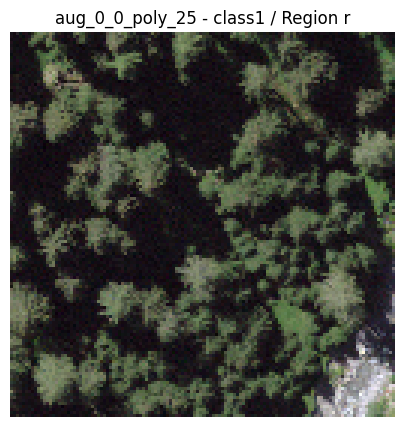

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Pfad zum Raster
raster_path = "/content/drive/MyDrive/ML_project/data/d/class1/aug_0_1_poly_91.tif"

# Raster laden
with rasterio.open(raster_path) as src:
    img = src.read()  # shape: (4, H, W)
    profile = src.profile

# RGB extrahieren (erste 3 Bänder)
rgb = img[:3, :, :]

# Rasterio liest als (B, H, W) → matplotlib erwartet (H, W, B)
rgb = np.moveaxis(rgb, 0, -1)

# Optional: Werte auf 0-255 strecken, falls Max < 255
for i in range(3):
    band = rgb[:, :, i]
    rgb[:, :, i] = ((band - band.min()) / (band.max() - band.min()) * 255).astype(np.uint8)

# Plot
plt.figure(figsize=(5, 5))
plt.imshow(rgb)
plt.title("aug_0_0_poly_25 - class1 / Region r")
plt.axis('off')
plt.show()


In [ ]:
import os
import numpy as np
import rasterio

# Ordner mit allen TIF-Dateien
data_folder = "/content/drive/MyDrive/ML_project/data"

# Listen für X und y
X_list = []
y_list = []

# Alle TIF-Dateien durchgehen
for fname in os.listdir(data_folder):
    if not fname.endswith(".tif"):
        continue

    file_path = os.path.join(data_folder, fname)

    with rasterio.open(file_path) as src:
        # Alle Bänder einlesen
        img = src.read()  # shape = (bands, height, width)

        # X = RGB (Bänder 1,2,3)
        X_rgb = img[0:3, :, :]  # shape = (3, H, W)
        X_list.append(X_rgb)

        # y = Band 4
        y_band4 = img[3, :, :]  # shape = (H, W)
        y_list.append(y_band4)

# In numpy arrays umwandeln
X = np.array(X_list)  # shape = (num_samples, 3, H, W)
y = np.array(y_list)  # shape = (num_samples, H, W)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (3200, 3, 128, 128)
y shape: (3200, 128, 128)


In [ ]:
X.shape[3]

128

array([[122, 124, 156, ...,  35,  70,  90],
       [160, 167, 116, ...,  61,  78,  93],
       [166, 119, 104, ...,  79,  72,  98],
       ...,
       [ 91,  74,  20, ...,  15,  37,  78],
       [ 68,  32,   7, ...,  43,  51,  66],
       [ 62,  17,   9, ...,  57,  77,  74]], dtype=uint8)
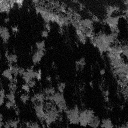

In [ ]:
X[1][0]

In [ ]:
X[1]

array([[[122, 124, 156, ...,  35,  70,  90],
        [160, 167, 116, ...,  61,  78,  93],
        [166, 119, 104, ...,  79,  72,  98],
        ...,
        [ 91,  74,  20, ...,  15,  37,  78],
        [ 68,  32,   7, ...,  43,  51,  66],
        [ 62,  17,   9, ...,  57,  77,  74]],

       [[137, 137, 159, ...,  48,  90, 101],
        [160, 169, 123, ...,  63,  97, 119],
        [163, 123, 115, ...,  98, 103, 119],
        ...,
        [114,  82,  25, ...,  31,  47,  91],
        [ 90,  44,  11, ...,  69,  63,  75],
        [ 73,  23,  10, ...,  90,  91,  96]],

       [[116, 120, 150, ...,  30,  65,  69],
        [152, 166, 105, ...,  62,  69,  80],
        [158, 109,  98, ...,  66,  72,  76],
        ...,
        [ 86,  59,  21, ...,  30,  36,  65],
        [ 67,  30,  10, ...,  44,  41,  56],
        [ 56,  21,  12, ...,  59,  58,  57]]], dtype=uint8)

In [ ]:
np.savez("/content/drive/MyDrive/ML_project/data_arrays.npz", X=X, y=y)


In [ ]:
data = np.load("/content/drive/MyDrive/ML_project/data_arrays.npz")
X = data['X']
y = data['y']